# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

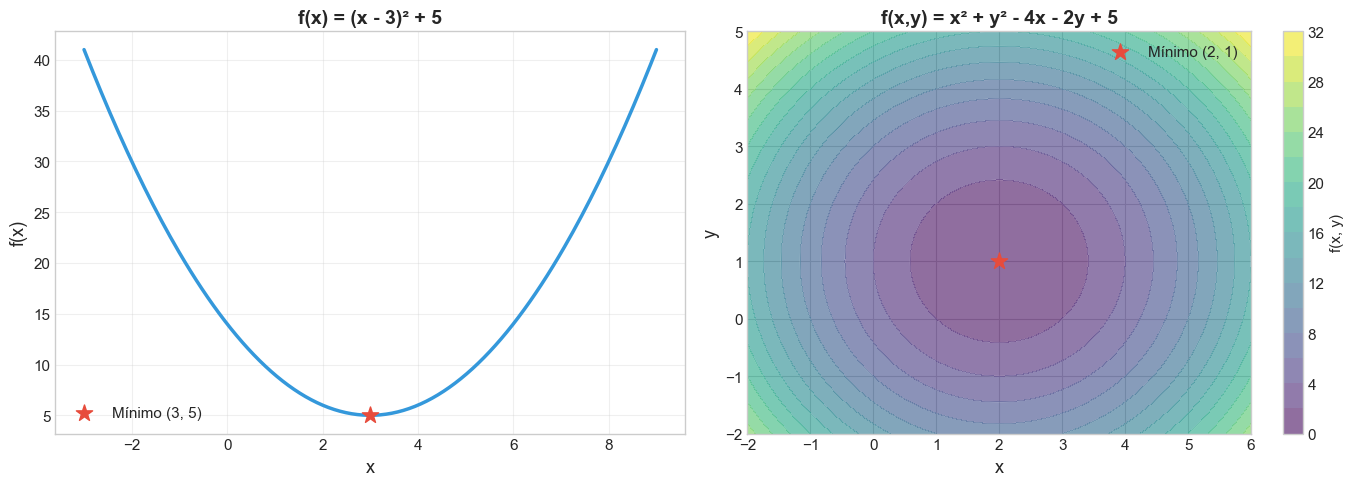

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [3]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa las variables:
    #    - x_actual = x_inicial
    #    - historial_x = [x_inicial]
    #    - historial_f = [f_1d(x_inicial)]
    #    - convergido = False
    
    # 2. Loop principal (max_iter iteraciones):
    #    a. Calcula el gradiente: g = df_1d(x_actual)
    #    b. Actualiza: x_nuevo = x_actual - learning_rate * g
    #    c. Guarda en historial
    #    d. Verifica convergencia: si |x_nuevo - x_actual| < tolerancia -> convergido
    #    e. Actualiza x_actual = x_nuevo
    
    # 3. Retorna el diccionario con resultados

    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False

    for i in range(max_iter):
        g = df_1d(x_actual) #calcula el gradiente
        
        x_nuevo = x_actual - learning_rate * g #actualiza la posición 
        
        historial_x.append(x_nuevo) #guarda el historial 
        historial_f.append(f_1d(x_nuevo))
        
        if abs(x_nuevo - x_actual) < tolerancia: #convergencia 
            convergido = True
            x_actual = x_nuevo
            break
        
        x_actual = x_nuevo #actualiza 
    
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,  # sin contar el punto inicial
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [35]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


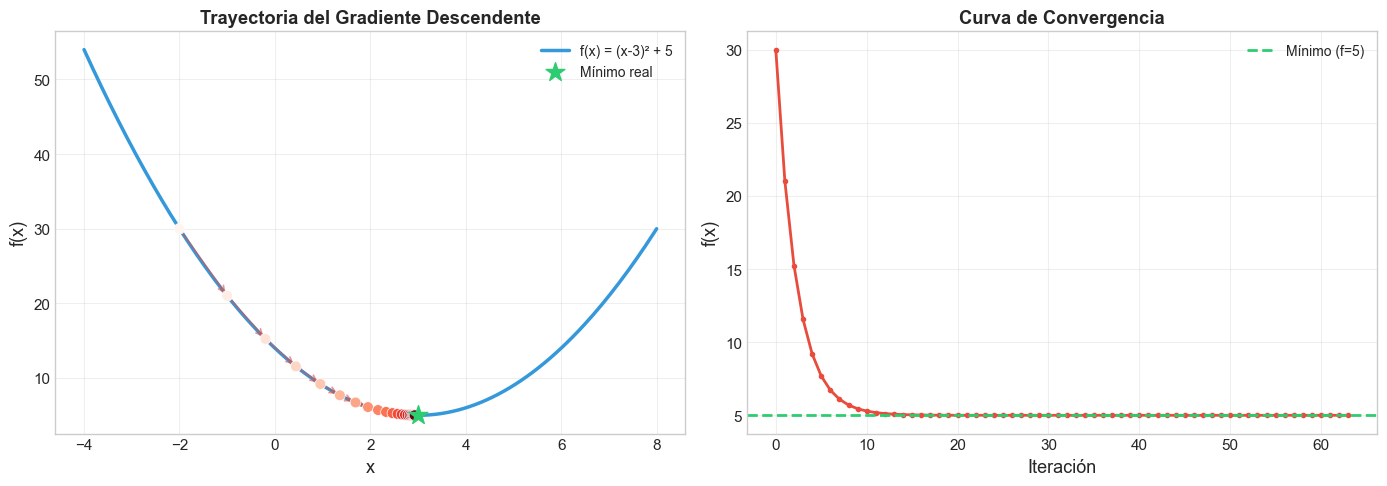

In [5]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [6]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr
for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(x_inicial=x_inicial_prueba,learning_rate=lr,max_iter=max_iter_prueba)
    resultados_lr.append(res)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergi\u00f3':>12}")

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

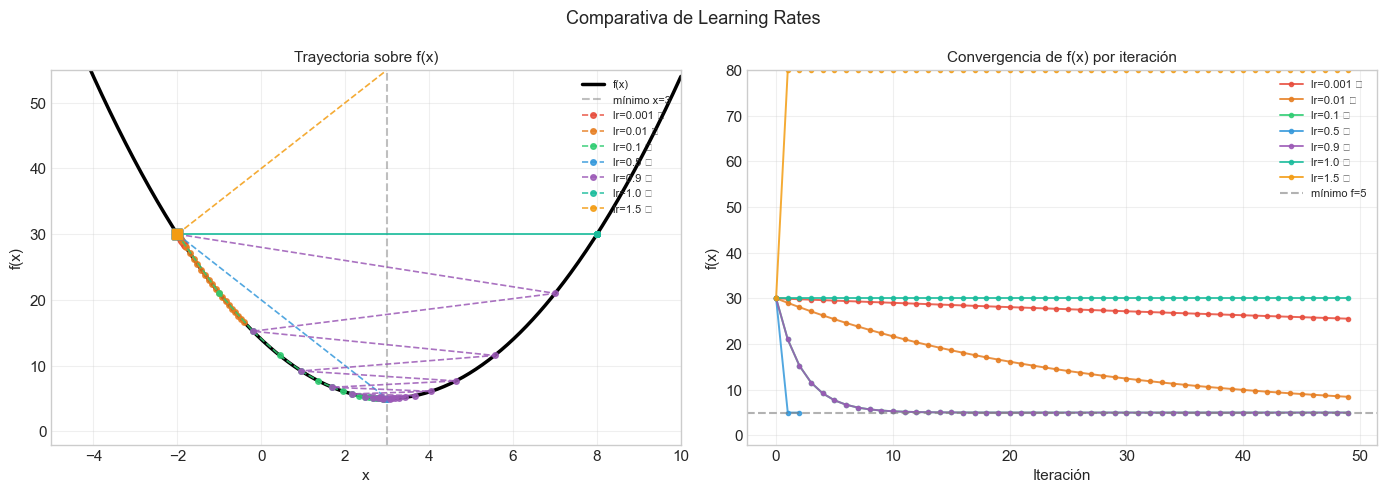

In [7]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

# Crea dos graficas:
# 1. Trayectoria sobre f(x) para cada LR (con diferentes colores)
# 2. Curva de convergencia f(x) vs iteracion para cada LR

# Pista: usa fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pista: usa colores distintos para cada LR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparativa de Learning Rates", fontsize=13)

colores = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c', '#f39c12']

#trayectoria sobre la curva f(x)
ax1 = axes[0]
x_vals = np.linspace(-5, 10, 400)
ax1.plot(x_vals, f_1d(x_vals), 'k-', linewidth=2.5, label='f(x)', zorder=2)
ax1.axvline(3, color='gray', linestyle='--', alpha=0.5, label='mínimo x=3')

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hx = res['historial_x'][:20]   # primeras 20 para no saturar
    hf = res['historial_f'][:20]
    etiqueta = f"lr={lr}" + (" ✓" if res['convergido'] else " ✗")
    ax1.plot(hx, hf, 'o--', color=color, markersize=4,
             linewidth=1.2, label=etiqueta, alpha=0.85)
    ax1.plot(hx[0], hf[0], 's', color=color, markersize=7, zorder=5)  # punto inicial

ax1.set_xlim(-5, 10)
ax1.set_ylim(-2, 55)
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('f(x)', fontsize=11)
ax1.set_title('Trayectoria sobre f(x)', fontsize=11)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(alpha=0.3)

#convergencia f(x) vs iteración
ax2 = axes[1]

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hf = res['historial_f'][:50]   # primeras 20 iteraciones
    iters = range(len(hf))
    etiqueta = f"lr={lr}" + (" ✓" if res['convergido'] else " ✗")
    hf_clip = np.clip(hf, -10, 80)
    ax2.plot(iters, hf_clip, 'o-', color=color, markersize=3,
             linewidth=1.4, label=etiqueta, alpha=0.85)

ax2.axhline(5, color='gray', linestyle='--', alpha=0.6, label='mínimo f=5')
ax2.set_ylim(-2, 80)
ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('f(x)', fontsize=11)
ax2.set_title('Convergencia de f(x) por iteración', fontsize=11)
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Responde estas preguntas basandote en tus experimentos:**

1. **\u00bfQu\u00e9 pasa con un learning rate muy peque\u00f1o (0.001)?**
   - *Tu respuesta:* Podemos notar que no converge, asi mismo, gráficamente hablando no se nota la trayectoria que sigue porque es minimo lo que se                         mueve, por lo que si queremos que converga, necesitamos más iteraciones.

2. **\u00bfCu\u00e1l consideras el mejor learning rate y por qu\u00e9?**
   - *Tu respuesta:* El mejor según los experimentos que se realizaron, es 0.500 puesto que en dos iteraciones logró converger, además tiene un                             x_final y un f(x)_final muy preciso.

3. **\u00bfQu\u00e9 pasa con learning rates >= 1.0?**
   - *Tu respuesta:* Se disparan completamente los valores de las x, dando resultados negativos y es claro que en las 200 iteraciones propuestas no converge.

4. **\u00bfPor qu\u00e9 un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funci\u00f3n?**
   - *Tu respuesta:* porque matemáticamente hablando si sustituimos en la regla de actualización siempre volvemos al -2, entonces nunca vonverge pero tampoco diverge, entonces podriamos decir que es el punto de estabilida de la función.

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [8]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa:
    #    - x_actual, y_actual = x_inicial, y_inicial
    #    - historiales vacios
    
    # 2. Loop principal:
    #    a. Calcula gradiente: g = grad_2d(x_actual, y_actual)  -> [gx, gy]
    #    b. Actualiza ambos parametros:
    #       x_nuevo = x_actual - lr * g[0]
    #       y_nuevo = y_actual - lr * g[1]
    #    c. Guarda en historiales
    #    d. Verifica convergencia: si ||gradiente|| < tolerancia -> convergido
    #       (norma del gradiente: np.linalg.norm(g))
    #    e. Actualiza x_actual, y_actual
    
    # 3. Retorna diccionario con resultados

    
    x_actual = x_inicial
    y_actual = y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False

    for _ in range(max_iter):

        g = grad_2d(x_actual, y_actual) # a. gadiente 

        if np.linalg.norm(g) < tolerancia: #verifica convergencia
            convergido = True
            break

        x_nuevo = x_actual - learning_rate * g[0] #actualiza los parametros 
        y_nuevo = y_actual - learning_rate * g[1]

        historial_x.append(x_nuevo) #guarda en un historial 
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))

        x_actual = x_nuevo #da el paso 
        y_actual = y_nuevo

    return {
        'x_final'    : x_actual,
        'y_final'    : y_actual,
        'f_final'    : f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido' : convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [36]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    72
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


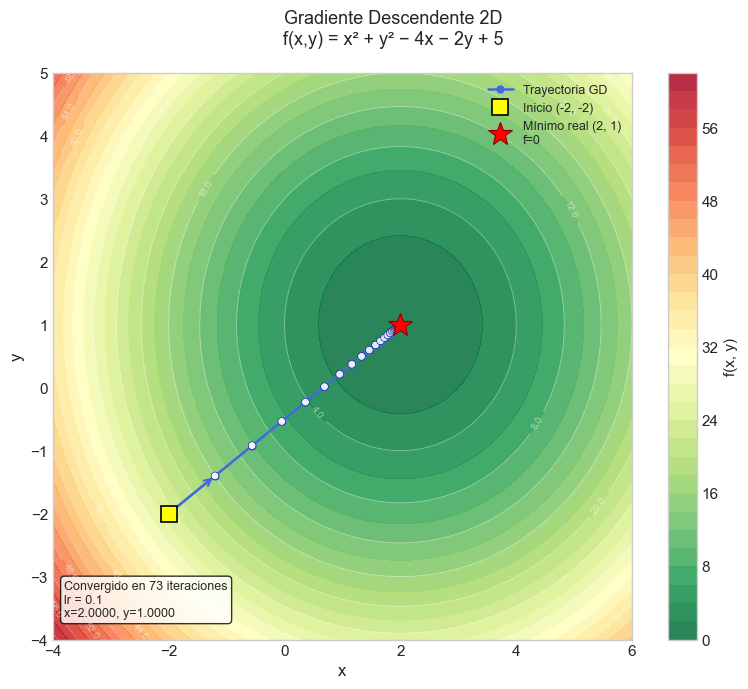

In [10]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria

res = gradiente_descendente_2d(-2, -2, learning_rate=0.1)

x_grid = np.linspace(-4, 6, 300)
y_grid = np.linspace(-4, 5, 300)
X, Y   = np.meshgrid(x_grid, y_grid)
Z      = f_2d(X, Y)

fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Gradiente Descendente 2D\nf(x,y) = x² + y² − 4x − 2y + 5", fontsize=13)

# 1. Fondo de color (mapa de calor continuo)
cf = ax.contourf(X, Y, Z, levels=30, cmap='RdYlGn_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='f(x, y)')

# 2. Líneas de contorno sobre el fondo
cs = ax.contour(X, Y, Z, levels=15, colors='white', linewidths=0.6, alpha=0.5)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f')

# 3. Trayectoria del descenso
hx = res['historial_x']
hy = res['historial_y']
ax.plot(hx, hy, 'o-', color='royalblue', markersize=5,
        linewidth=1.8, label='Trayectoria GD', zorder=4)

scatter = ax.scatter(hx, hy, c=range(len(hx)), cmap='Blues',
                     s=30, zorder=5, edgecolors='navy', linewidths=0.4)

# 4. Punto de inicio
ax.plot(hx[0], hy[0], 's', color='yellow', markersize=12,
        zorder=6, label=f'Inicio ({hx[0]:.0f}, {hy[0]:.0f})',
        markeredgecolor='black', markeredgewidth=1.2)

# 5. Mínimo real
ax.plot(2, 1, '*', color='red', markersize=18,
        zorder=7, label='Mínimo real (2, 1)\nf=0',
        markeredgecolor='darkred', markeredgewidth=0.8)

paso = max(1, len(hx) // 8)
for i in range(0, len(hx) - 1, paso):
    dx = hx[i+1] - hx[i]
    dy = hy[i+1] - hy[i]
    ax.annotate('', xy=(hx[i+1], hy[i+1]), xytext=(hx[i], hy[i]),
                arrowprops=dict(arrowstyle='->', color='royalblue',
                                lw=1.5, mutation_scale=12))

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_xlim(-4, 6)
ax.set_ylim(-4, 5)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.2, color='white')

# Anotación del número de iteraciones
ax.text(0.02, 0.04,
        f"Convergido en {res['iteraciones']} iteraciones\n"
        f"lr = 0.1\n"
        f"x={res['x_final']:.4f}, y={res['y_final']:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados
colores_tray = ['#e74c3c', '#3498db', '#2ecc71']
marcadores   = ['s', 'D', '^']

resultados_2d = []
for (xi, yi) in puntos_iniciales:
    res = gradiente_descendente_2d(xi, yi, learning_rate=0.1)
    resultados_2d.append(res)

# ── Tabla de resultados ───────────────────────────────────────────
print("EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES")
print(f"{'Inicio':>14} {'x_final':>10} {'y_final':>10} {'f_final':>10} {'Iters':>7} {'Conv.':>7}")
for (xi, yi), res in zip(puntos_iniciales, resultados_2d):
    print(f"({xi:4.1f}, {yi:4.1f})   "
          f"{res['x_final']:>10.6f} {res['y_final']:>10.6f} "
          f"{res['f_final']:>10.6f} {res['iteraciones']:>7} {str(res['convergido']):>7}")


EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES
        Inicio    x_final    y_final    f_final   Iters   Conv.
(-1.0,  4.0)     2.000000   1.000000   0.000000      72    True
( 5.0, -1.0)     2.000000   1.000000   0.000000      71    True
( 0.0,  0.0)     2.000000   1.000000   0.000000      69    True


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [18]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

# 1. Ejecuta TODOS los experimentos:
#    - 1D: learning_rates [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
#           desde x=-2.0
#    - 2D: learning_rates [0.001, 0.01, 0.1, 0.5]
#           desde (-1, 4), (5, -1), (0, 0)

# 2. Crea el DataFrame

# 3. Guardalo como CSV

# df_experimentos = pd.DataFrame(...)
# df_experimentos.to_csv('experimentos_gd.csv', index=False)

learning_rates_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_1d = -2.0
filas = []

for lr in learning_rates_1d:
    res = gradiente_descendente_1d(x_inicial_1d, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr,
        'dimension'    : '1D',
        'x_inicial'    : x_inicial_1d,
        'y_inicial'    : np.nan,
        'x_final'      : res['x_final'],
        'y_final'      : np.nan,
        'valor_minimo' : res['f_final'],
        'iteraciones'  : res['iteraciones'],
        'convergido'   : res['convergido'],
    })

#experimentos 2d
learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_2d= [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for lr in learning_rates_2d:
    for (xi, yi) in puntos_2d:
        res = gradiente_descendente_2d(xi, yi, learning_rate=lr, max_iter=200)
        filas.append({
            'learning_rate': lr,
            'dimension'    : '2D',
            'x_inicial'    : xi,
            'y_inicial'    : yi,
            'x_final'      : res['x_final'],
            'y_final'      : res['y_final'],
            'valor_minimo' : res['f_final'],
            'iteraciones'  : res['iteraciones'],
            'convergido'   : res['convergido'],
        })

In [19]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -1.015484e-02  3.010155  8.081445e+00  

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **\u00bfCu\u00e1l es el rango de learning rates que funciona bien para estas funciones?**
   - *Tu respuesta:* 0.500 puesto que en ambas dimensiones solo le toma 2 iteraciones converger, asi mismo hay otros puntos que de igual manera congerven rapidamente, pero no como el 0.500

2. **\u00bfEl punto inicial afecta si el algoritmo converge? \u00bfAfecta cu\u00e1ntas iteraciones necesita?**
   - *Tu respuesta:* Debido a la naturaleza de la función, como es convexa el punto inicial no afecta si converge, sin embargo con 0.001 para los tres valores de x si quedan en posiciones completamente distintas, demostrando que cuando el learning rate falla, el punto inicial sí determina dónde termina la trayectoria

3. **\u00bfQu\u00e9 pasar\u00eda si la funci\u00f3n tuviera m\u00faltiples m\u00ednimos locales? (piensa en una funci\u00f3n como `sin(x) + x\u00b2/10`)**
   - *Tu respuesta:* El gradiente descediente siempre tenderia hacia el mínimo más cercano al punto inicial, sin capacidad de probar si existe uno mejor más lejos.

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la funci\u00f3n de costo es como `f(x,y)`. \u00bfPor qu\u00e9 es importante elegir bien el learning rate al entrenar?**
   - *Tu respuesta:* Es importante elegir los pesos de x e y debido a que todo depende de esos valores, es decir, si se tiene un peso muy pequeño puede que el modelo tarde muhcisimo en aprender y esto es computacionalmente costoso, por otro lado, si los pesos son muy grandes el modelo quedaria completamente inservible. Asi que lo ideal es buscar un learning rate que converga de forma eficiente. 

5. **\u00bfQu\u00e9 ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Tu respuesta:* El CSV lo demuestra, ya que con gradiente descendente encontró el mínimo exacto en 2 iteraciones desde cualquier punto en un espacio 2D. Una búsqueda aleatoria tendría que muestrear el espacio infinito sin ninguna garantía de acercarse al mínimo

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [20]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [37]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa w = 0, b = 0
    # 2. Para cada epoch:
    #    a. Mezcla los indices aleatoriamente
    #    b. Para cada mini-batch:
    #       - Selecciona batch_size muestras
    #       - Calcula prediccion: y_pred = w * X_batch + b
    #       - Calcula error: error = y_batch - y_pred
    #       - Calcula gradientes:
    #           dw = -2/batch_size * sum(error * X_batch)
    #           db = -2/batch_size * sum(error)
    #       - Actualiza: w = w - lr * dw, b = b - lr * db
    #    c. Calcula MSE del epoch completo y guarda en historial
    
    w = 0.0
    b = 0.0
    n = len(X)
    historial_loss = []
    historial_w    = []
    historial_b    = []

    for epoch in range(epochs):
        indices = np.random.permutation(n) #mezclar indices 
        
        for start in range(0, n, batch_size):  
            idx        = indices[start : start + batch_size]
            X_batch    = X[idx]
            y_batch    = y[idx]

            y_pred  = w * X_batch + b
            error   = y_batch - y_pred

            dw = -2 / len(idx) * np.sum(error * X_batch)
            db = -2 / len(idx) * np.sum(error)

            w = w - learning_rate * dw
            b = b - learning_rate * db

        y_pred_full = w * X + b
        mse         = np.mean((y - y_pred_full) ** 2)

        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final'       : w,
        'b_final'       : b,
        'historial_loss': historial_loss,
        'historial_w'   : historial_w,
        'historial_b'   : historial_b,
    }

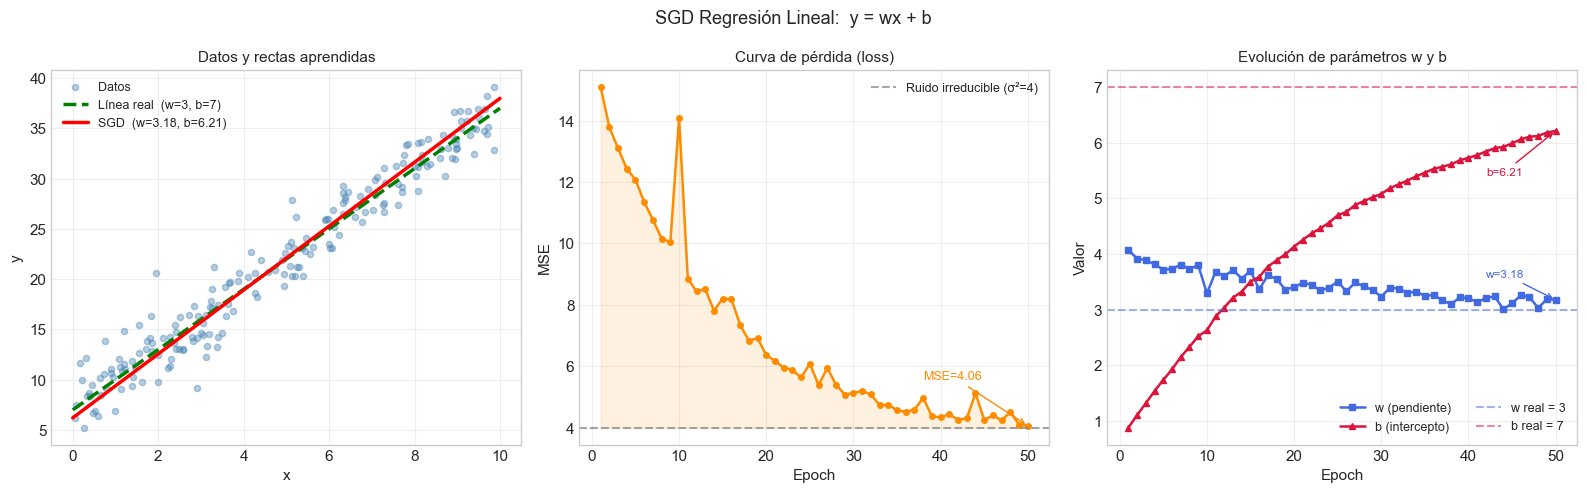

In [38]:
# Ejecuta SGD y visualiza resultados

# resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:
# 1. Datos + linea aprendida por SGD vs linea real
# 2. Curva de loss por epoch
# 3. Evolucion de w y b por epoch

resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("SGD Regresión Lineal:  y = wx + b", fontsize=13)

epochs_eje = range(1, 51)

# real vs predicho 
ax1 = axes[0]
ax1.scatter(X_sgd, y_sgd, alpha=0.4, s=20, color='steelblue', label='Datos')

x_line = np.linspace(0, 10, 200)
ax1.plot(x_line, 3*x_line + 7,
         'g--', linewidth=2.5, label='Línea real  (w=3, b=7)')
ax1.plot(x_line,
         resultado_sgd['w_final']*x_line + resultado_sgd['b_final'],
         'r-',  linewidth=2.5,
         label=f"SGD  (w={resultado_sgd['w_final']:.2f}, b={resultado_sgd['b_final']:.2f})")

ax1.set_xlabel('x',    fontsize=11)
ax1.set_ylabel('y',    fontsize=11)
ax1.set_title('Datos y rectas aprendidas', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

#cruva loss
ax2 = axes[1]
ax2.plot(epochs_eje, resultado_sgd['historial_loss'],
         'o-', color='darkorange', markersize=4, linewidth=1.8)
ax2.axhline(4.0, color='gray', linestyle='--', alpha=0.7,
            label='Ruido irreducible (σ²=4)')
ax2.fill_between(epochs_eje, resultado_sgd['historial_loss'], 4.0,
                 alpha=0.12, color='darkorange')

ax2.set_xlabel('Epoch',  fontsize=11)
ax2.set_ylabel('MSE',    fontsize=11)
ax2.set_title('Curva de pérdida (loss)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# anotación del valor final
ax2.annotate(f"MSE={resultado_sgd['historial_loss'][-1]:.2f}",
             xy=(50, resultado_sgd['historial_loss'][-1]),
             xytext=(38, resultado_sgd['historial_loss'][-1]+1.5),
             arrowprops=dict(arrowstyle='->', color='darkorange'),
             fontsize=9, color='darkorange')

# w y b por epoch
ax3 = axes[2]

ax3.plot(epochs_eje, resultado_sgd['historial_w'],
         's-', color='royalblue', markersize=4, linewidth=1.8, label='w (pendiente)')
ax3.plot(epochs_eje, resultado_sgd['historial_b'],
         '^-', color='crimson',   markersize=4, linewidth=1.8, label='b (intercepto)')

ax3.axhline(3, color='royalblue', linestyle='--', alpha=0.5, label='w real = 3')
ax3.axhline(7, color='crimson',   linestyle='--', alpha=0.5, label='b real = 7')

ax3.set_xlabel('Epoch',     fontsize=11)
ax3.set_ylabel('Valor',     fontsize=11)
ax3.set_title('Evolución de parámetros w y b', fontsize=11)
ax3.legend(fontsize=9, ncol=2)
ax3.grid(alpha=0.3)

# anotaciones de valores finales
ax3.annotate(f"w={resultado_sgd['w_final']:.2f}",
             xy=(50, resultado_sgd['w_final']),
             xytext=(42, resultado_sgd['w_final']+0.4),
             fontsize=8.5, color='royalblue',
             arrowprops=dict(arrowstyle='->', color='royalblue', lw=1))
ax3.annotate(f"b={resultado_sgd['b_final']:.2f}",
             xy=(50, resultado_sgd['b_final']),
             xytext=(42, resultado_sgd['b_final']-0.8),
             fontsize=8.5, color='crimson',
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1))

plt.tight_layout()
plt.show()

In [31]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

# batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

# TU CODIGO: ejecuta para cada batch_size y compara convergencia
batch_sizes   = [1, 8, 32, 64, n_datos]
etiquetas     = {1: 'SGD puro (bs=1)', 8: 'Mini-batch 8',
                 32: 'Mini-batch 32', 64: 'Mini-batch 64',
                 n_datos: f'GD puro (bs={n_datos})'}
colores       = ['#e74c3c','#e67e22','#3498db','#9b59b6','#2ecc71']

resultados_bs = {}
for bs in batch_sizes:
    resultados_bs[bs] = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)

In [39]:
tipos = {1:'SGD puro', 8:'Mini-batch', 32:'Mini-batch', 64:'Mini-batch', n_datos:'GD puro'}

print('COMPARACIÓN GD vs SGD - DIFERENTES BATCH SIZES')
print(f"{'Batch Size':>14}  {'w_final':>9}  {'b_final':>9}  {'MSE final':>10}  {'Tipo'}")
for bs in batch_sizes:
    r = resultados_bs[bs]
    print(f"{bs:>14}  {r['w_final']:>9.4f}  {r['b_final']:>9.4f}  {r['historial_loss'][-1]:>10.4f}  {tipos[bs]}")

COMPARACIÓN GD vs SGD - DIFERENTES BATCH SIZES
    Batch Size    w_final    b_final   MSE final  Tipo
             1     2.9842     7.2243      3.7355  SGD puro
             8     3.0301     7.2211      3.8071  Mini-batch
            32     3.1354     6.1802      4.0222  Mini-batch
            64     3.3328     4.9075      5.1658  Mini-batch
           200     3.7556     2.1410     10.6685  GD puro


**Preguntas Bonus:**

1. **\u00bfQu\u00e9 diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *Tu respuesta:* son completamente opuestos, porque el GD puro calcula el gradiente perfecto en cada paso, pero ese gradiente es tan pequeño con learning rate de 0.01 que avanza muy lento. El SGD puro da pasos grandes e impredecibles 

2. **\u00bfCu\u00e1l batch_size te dio los mejores resultados? \u00bfPor qu\u00e9?**
   - *Tu respuesta:* el 8, puesto que 8 muestras ya promedian bastante el ruido aleatorio, dando un gradiente razonablemente confiable en cada paso, además de que con bs=8 se hacen 25 actualizaciones por epoch vs 1 del GD puro, lo que compensa creces el learnign rate pequeño.

3. **\u00bfPor qu\u00e9 la curva de loss de SGD es m\u00e1s ruidosa que la de GD?**
   - *Tu respuesta:* Porque el gradiente calculado con una sola muestra es una estimación muy ruidosa del gradiente real.

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_